# QFM-Conditioned Pixel Diffusion on Quark/Gluon Jet Images (QG)

This notebook ports the **QFM-conditioned diffusion** idea from `hybrid_dm.ipynb` to the **QG jet dataset**.

## Core idea
- We keep the **diffusion process in pixel space** (stable sampling, no fragile decode).
- We feed a **quantum / quantum-inspired feature map** as **conditioning** to the denoiser.

In this repo, we already have a patch-based quantum encoding for QG stored as `..._encoded.pt` (4 channels on a 32x32 grid for 64x64 images). We upsample those features and concatenate them to the noisy image input.

This is the most QG-ready hybrid path because it does **not** rely on MNIST-style masking or analytic decoding.


In [72]:
%cd /Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model

import math
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity as ssim

device = torch.device('cuda' if torch.cuda.is_available() else 'mps') if torch.backends.mps.is_available() else torch.device('cpu')
print('Device:', device)

/Users/masha/Documents/GSOC/GSoC-Quantum-Diffusion-Model
Device: mps


## 1. Load QG data (same style as other notebooks)
We mirror the preprocessing pattern used in `notebooks/classical/fm_hep.ipynb`.
If you want to exactly match a previously saved encoding, set `preprocess=False`.


In [73]:
QG_channel = 1

# Comparison setup:
# - Pixel diffusion baseline: 1000 raw samples (no augmentation)
# - QFM-conditioned model: 500 raw samples, augmented to 2 views/sample via post-encoding scrambling
num_samples_px = 1000
num_samples_qfm = 500

filename = f'data/QG{QG_channel}_64x64_1k'
max_samples = max(num_samples_px, num_samples_qfm)

data_X = np.array(h5py.File(filename, 'r')['X'])[:max_samples]
print('Raw data shape:', data_X.shape)

# Aggressive but stable default: work in intensity space [0, 1] (no [-1,1] remap)
preprocess = True
center_data = True

if preprocess:
    data_X = data_X.astype(np.float32)
    data_X = np.log1p(data_X)
    data_X = data_X / (data_X.max() + 1e-8)

x_px_all = torch.tensor(data_X, dtype=torch.float32).unsqueeze(1)  # (N,1,64,64) in [0,1]

@torch.no_grad()
def center_by_energy_centroid_zeropad(x01):
    # x01: (N,1,H,W) in [0,1]
    N, _, H, W = x01.shape
    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = torch.round((H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)).to(torch.int64)
    tx = torch.round((W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)).to(torch.int64)

    out = torch.zeros_like(x01)

    for i in range(N):
        dy = int(ty[i].item())
        dx = int(tx[i].item())
        src_y0 = max(0, -dy)
        dst_y0 = max(0, dy)
        h = H - max(0, dy) - max(0, -dy)
        src_x0 = max(0, -dx)
        dst_x0 = max(0, dx)
        w_ = W - max(0, dx) - max(0, -dx)
        if h > 0 and w_ > 0:
            out[i, :, dst_y0:dst_y0+h, dst_x0:dst_x0+w_] = x01[i, :, src_y0:src_y0+h, src_x0:src_x0+w_]

    return out

if center_data:
    x_px_all = center_by_energy_centroid_zeropad(x_px_all)

# Subsets used by each model
x_px_full = x_px_all[:num_samples_px]
x_px = x_px_all[:num_samples_qfm]

print('Pixel tensor (all):', x_px_all.shape, 'range:', float(x_px_all.min()), float(x_px_all.max()))
print('Pixel baseline (x_px_full):', x_px_full.shape)
print('Pixel subset for QFM (x_px):', x_px.shape)



Raw data shape: (1000, 64, 64)
Pixel tensor (all): torch.Size([1000, 1, 64, 64]) range: 0.0 1.0
Pixel baseline (x_px_full): torch.Size([1000, 1, 64, 64])
Pixel subset for QFM (x_px): torch.Size([500, 1, 64, 64])


### Quick visualization


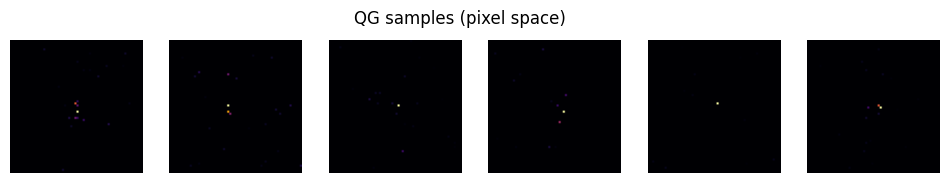

In [74]:
def show_imgs(x, n=6, title=''):
    x = x[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        axes[i].imshow(x[i,0], cmap='inferno')
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

show_imgs(x_px, title='QG samples (pixel space)')


## 2. Load quantum/encoded conditioning features
We load the stored patch-encoding used by `64fully_quantum.ipynb`:
- shape typically `(N, 32, 32, 4)`
We convert to channels-first and upsample to 64x64 for conditioning.


In [75]:
# QFM / quantum encoding for conditioning
# Option A (recommended for alignment): generate q_enc directly from the same pixel tensor you train on.
# Option B (fast): load precomputed encodings from disk.

generate_q_enc = True
qenc_source = 'pixel'  # 'pixel' (uses x_px) or 'raw' (uses data_X before preprocessing)
use_entangled_patch = True

# Small 2x2-patch circuit -> 4 features (one per qubit)
dev_qenc = qml.device('default.qubit', wires=4)

@qml.qnode(dev_qenc)
def patch_circuit(phi):
    # phi: length-4 array
    for j in range(4):
        qml.RX(np.pi * float(phi[j]), wires=j)

    if use_entangled_patch:
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])
        qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(j)) for j in range(4)]

def angle_encode_batch(x_np):
    # x_np: (N, 64, 64)
    N, H, W = x_np.shape
    out = np.zeros((N, H // 2, W // 2, 4), dtype=np.float32)

    for n in range(N):
        for i in range(0, H, 2):
            for j in range(0, W, 2):
                phi = [
                    x_np[n, i, j],
                    x_np[n, i, j + 1],
                    x_np[n, i + 1, j],
                    x_np[n, i + 1, j + 1],
                ]
                out[n, i // 2, j // 2, :] = patch_circuit(phi)
        if (n + 1) % 50 == 0:
            print(f'Encoded {n+1}/{N}', end='')

    return out

if generate_q_enc:
    if qenc_source == 'pixel':
        x_for_qenc = x_px.squeeze(1).detach().cpu().numpy()
    elif qenc_source == 'raw':
        x_for_qenc = data_X.copy()
    else:
        raise ValueError("qenc_source must be 'pixel' or 'raw'")

    q_enc_np = angle_encode_batch(x_for_qenc)
    q_enc = torch.tensor(q_enc_np, dtype=torch.float32)
else:
    enc_path = f'data/QG{QG_channel}_64x64_{num_samples_qfm}_encoded.pt'
    q_enc = torch.load(enc_path, map_location='cpu')

print('Encoded shape (NHWC):', q_enc.shape)

# Convert to (N, C, H, W)
if q_enc.ndim == 4 and q_enc.shape[-1] == 4:
    q_enc = q_enc.permute(0, 3, 1, 2).contiguous()

print('Encoded (N,C,H,W):', q_enc.shape)

def upsample_cond(q):
    # q: (N,C,32,32) -> (N,C,64,64)
    return F.interpolate(q, size=(64, 64), mode='bilinear', align_corners=False)

Encoded 50/500Encoded 100/500Encoded 150/500Encoded 200/500Encoded 250/500Encoded 300/500Encoded 350/500Encoded 400/500Encoded 450/500Encoded 500/500Encoded shape (NHWC): torch.Size([500, 32, 32, 4])
Encoded (N,C,H,W): torch.Size([500, 4, 32, 32])


## 3. Train/Val split + loaders


In [76]:
train_px_full, val_px_full = train_test_split(x_px_full, test_size=0.2, random_state=42, shuffle=True)
train_px, val_px, train_q, val_q = train_test_split(x_px, q_enc, test_size=0.2, random_state=42, shuffle=True)

# Quantum post-encoding augmentation (paper-style scrambling):
# - Keep the classical pixel baseline at 1000 samples (no duplication).
# - For the QFM-conditioned model only, add 1 scrambled conditioning per sample.
# - Scrambler is a shallow hardware-mappable circuit: RY rotations + CNOT chain.

augment_qenc = True
aug_depth = 2
aug_shared_unitary = True
aug_seed = 123

q_dim = int(train_q[0].numel())
n_qubits_aug = int(np.log2(q_dim))
if 2 ** n_qubits_aug != q_dim:
    raise ValueError(f"Encoded conditioning dimension must be a power of two; got {q_dim}")

def _make_cnot_perm(n_qubits, control, target):
    dim = 2 ** n_qubits
    idx = torch.arange(dim, dtype=torch.long)
    mask = (idx >> control) & 1
    perm = idx.clone()
    perm[mask == 1] = perm[mask == 1] ^ (1 << target)
    return perm

@torch.no_grad()
def _apply_ry(state, theta, qubit, n_qubits):
    # state: (B, 2**n), theta: (B,)
    B = state.shape[0]
    dim_hi = 2 ** (n_qubits - qubit - 1)
    dim_lo = 2 ** qubit

    psi = state.view(B, dim_hi, 2, dim_lo)
    a0 = psi[:, :, 0, :]
    a1 = psi[:, :, 1, :]

    half = 0.5 * theta
    c = torch.cos(half).view(B, 1, 1)
    s = torch.sin(half).view(B, 1, 1)

    b0 = c * a0 - s * a1
    b1 = s * a0 + c * a1
    return torch.stack([b0, b1], dim=2).reshape(B, -1)

@torch.no_grad()
def scramble_qenc_batch(q, depth=2, seed=123, shared_unitary=True, n_qubits=12):
    # q: (B,C,H,W) real tensor; treated as a 2**n vector per sample
    B = q.shape[0]
    flat = q.view(B, -1)
    if flat.shape[1] != 2 ** n_qubits:
        raise ValueError(f"Expected dim={2**n_qubits} but got {flat.shape[1]}")

    # Normalize to a unit vector (valid state amplitudes), but rescale back after scrambling
    norm = flat.norm(dim=1, keepdim=True).clamp_min(1e-8)
    state = flat / norm

    # Generate angles on CPU for MPS compatibility, then move to device
    gen = torch.Generator(device='cpu')
    gen.manual_seed(int(seed))
    if shared_unitary:
        thetas = 2 * math.pi * torch.rand((depth, n_qubits), generator=gen)
        thetas = thetas.unsqueeze(0).expand(B, -1, -1)
    else:
        thetas = 2 * math.pi * torch.rand((B, depth, n_qubits), generator=gen)
    thetas = thetas.to(state.device)

    # CNOT chain perms (control=i, target=i+1)
    perms = [_make_cnot_perm(n_qubits, i, i + 1).to(state.device) for i in range(n_qubits - 1)]

    for d in range(depth):
        for qb in range(n_qubits):
            state = _apply_ry(state, thetas[:, d, qb], qb, n_qubits)
        for p in perms:
            state = state.index_select(1, p)

    flat_scr = state * norm
    return flat_scr.view_as(q)

# Loader for pixel baseline (no augmentation, stays at 1000 samples)
dummy_px = torch.zeros((train_px_full.shape[0], 1), dtype=torch.float32)
train_loader_px = DataLoader(TensorDataset(train_px_full, dummy_px), batch_size=64, shuffle=True)

# Loader for QFM-conditioned model (duplicate x, scramble q once)
if augment_qenc:
    train_q_aug = scramble_qenc_batch(
        train_q.to(device),
        depth=aug_depth,
        seed=aug_seed,
        shared_unitary=aug_shared_unitary,
        n_qubits=n_qubits_aug,
    ).cpu()
    train_px_q = torch.cat([train_px, train_px], dim=0)
    train_q_q = torch.cat([train_q, train_q_aug], dim=0)
else:
    train_px_q, train_q_q = train_px, train_q

train_loader_q = DataLoader(TensorDataset(train_px_q, train_q_q), batch_size=64, shuffle=True)

val_loader = DataLoader(TensorDataset(val_px, val_q), batch_size=64, shuffle=False)
print('Train(px, baseline):', train_px_full.shape)
print('Train(qfm raw):      ', train_px.shape, train_q.shape)
print('Train(qfm views):    ', train_px_q.shape, train_q_q.shape)
print('Val(qfm):            ', val_px.shape, val_q.shape)
print('Val(px, baseline):   ', val_px_full.shape)

Train(px, baseline): torch.Size([800, 1, 64, 64])
Train(qfm raw):       torch.Size([400, 1, 64, 64]) torch.Size([400, 4, 32, 32])
Train(qfm views):     torch.Size([800, 1, 64, 64]) torch.Size([800, 4, 32, 32])
Val(qfm):             torch.Size([100, 1, 64, 64]) torch.Size([100, 4, 32, 32])
Val(px, baseline):    torch.Size([200, 1, 64, 64])


## 4. Diffusion utilities (DDPM-style, epsilon prediction)


In [77]:
def cosine_beta_schedule(timesteps, s=0.008):
    # Nichol & Dhariwal cosine schedule
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps) / timesteps
    alphas_cumprod = torch.cos((x + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 1e-6, 0.999)

T = 200
betas = cosine_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    out = a.gather(-1, t).float()
    return out.view(-1, 1, 1, 1)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x0.shape)
    return sqrt_ac * x0 + sqrt_om * noise

def predict_x0_from_noise(x_t, t, eps):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_om * eps) / sqrt_ac

def predict_eps_from_x0(x_t, t, x0):
    sqrt_ac = extract(sqrt_alphas_cumprod, t, x_t.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    return (x_t - sqrt_ac * x0) / sqrt_om



## 5. Models
We train:
- a **pixel baseline** denoiser `p(eps | x_t, t)`
- a **QFM-conditioned** denoiser `p(eps | x_t, qfm(x0), t)`

Both are small time-conditional U-Nets.


In [78]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, padding_mode='reflect'),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, padding_mode='reflect'),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x, t_emb):
        h = self.conv(x)
        h = h + self.time_proj(t_emb)[:, :, None, None]
        return h, self.pool(h)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        # Resize-convolution upsampling avoids ConvTranspose2d checkerboard artifacts
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_ch, out_ch, 3, padding=1, padding_mode='reflect'),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )
        self.conv = DoubleConv(out_ch * 2, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = x + self.time_proj(t_emb)[:, :, None, None]
        return x

class TimeEmbedding(nn.Module):
    def __init__(self, n_steps, time_dim):
        super().__init__()
        self.embedding = nn.Embedding(n_steps, time_dim)
        self.mlp = nn.Sequential(nn.Linear(time_dim, time_dim), nn.SiLU())
    def forward(self, t):
        return self.mlp(self.embedding(t))

class SimpleUNet(nn.Module):
    def __init__(self, in_channels, out_channels, base=64, time_dim=128, n_steps=200):
        super().__init__()
        self.time_emb = TimeEmbedding(n_steps, time_dim)
        self.down1 = Down(in_channels, base, time_dim)
        self.down2 = Down(base, base * 2, time_dim)
        self.bot = DoubleConv(base * 2, base * 4)
        self.up2 = Up(base * 4, base * 2, time_dim)
        self.up1 = Up(base * 2, base, time_dim)
        self.out = nn.Conv2d(base, out_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_emb(t)
        h1, x = self.down1(x, t_emb)
        h2, x = self.down2(x, t_emb)
        x = self.bot(x)
        x = self.up2(x, h2, t_emb)
        x = self.up1(x, h1, t_emb)
        return self.out(x)



## 6. Train baseline + conditioned models


In [79]:
# Reproducibility
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Aggressive training objective for sparse jets:
# - predict x0 directly (instead of eps)
# - add sparsity-aware auxiliary losses (top-k pixels, active fraction, energy, radial profile)

use_sparsity_losses = False

# Sparsity knobs
k_top = 64
w_topk = 5.0

thr_active = 0.08
temp_active = 0.02
w_active = 2.0

w_energy = 1.0

radial_bins = 32
w_radial = 1.0

# Precompute radial bin weights for 64x64
H = W = 64
_yy, _xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
_rr = torch.sqrt((_yy - H // 2) ** 2 + (_xx - W // 2) ** 2).float()
_rmax = float(_rr.max())
_edges = torch.linspace(0.0, _rmax + 1e-6, radial_bins + 1)

_bin_w = []
for b in range(radial_bins):
    m = ((_rr >= _edges[b]) & (_rr < _edges[b + 1])).float()
    _bin_w.append(m)

bin_w = torch.stack(_bin_w, dim=0).to(device)         # (B,H,W)
bin_w_flat = bin_w.view(radial_bins, -1)              # (B,P)
bin_norm = bin_w_flat.sum(dim=1).clamp_min(1.0)       # (B,)

@torch.no_grad()
def radial_profile01(x01):
    # x01: (N,1,H,W) -> (N,B)
    x_flat = x01.view(x01.shape[0], -1)
    prof = (x_flat @ bin_w_flat.T) / bin_norm
    return prof

@torch.no_grad()
def topk_mask01(x01, k):
    N = x01.shape[0]
    flat = x01.view(N, -1)
    k = min(k, flat.shape[1])
    _, idx = torch.topk(flat, k, dim=1)
    mask = torch.zeros_like(flat)
    mask.scatter_(1, idx, 1.0)
    return mask.view_as(x01)

model_px = SimpleUNet(in_channels=1, out_channels=2, base=64, time_dim=128, n_steps=T).to(device)
model_px_qfm = SimpleUNet(in_channels=1 + q_enc.shape[1], out_channels=2, base=64, time_dim=128, n_steps=T).to(device)

opt_px = torch.optim.Adam(model_px.parameters(), lr=2e-4)
opt_q = torch.optim.Adam(model_px_qfm.parameters(), lr=2e-4)

# Fixed validation batch + fixed noise/timestep for apples-to-apples comparison across epochs
val_batch_fixed = val_px[:64].to(device)
val_cond_fixed = upsample_cond(val_q[:64].to(device))

eval_gen = torch.Generator(device=device).manual_seed(seed + 1)

# Two-head x0 predictor: (occupancy logit, intensity logit)
# We decode to x0 in [0,1] via: x0_hat = sigmoid(occ_logit) * sigmoid(int_logit)
occ_thr = 0.01
w_occ = 1.0
w_int = 5.0
w_bg = 0.1

# Conditioning dropout (classifier-free guidance style):
# With probability cond_drop_p, we zero out q_enc so the model also learns an unconditional path.
cond_drop_p = 0.1

def decode_x0_from_heads(out):
    # out: (N,2,H,W)
    occ_logit = out[:, :1]
    int_logit = out[:, 1:2]
    occ_prob = torch.sigmoid(occ_logit)
    intensity = torch.sigmoid(int_logit)
    x0_hat = occ_prob * intensity
    return x0_hat, occ_logit, intensity, occ_prob


def eval_x0_loss_fixed(model, x0, cond=None, t_val=None):
    model.eval()
    with torch.no_grad():
        if t_val is None:
            t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
        eps = torch.randn(x0.shape, device=device, generator=eval_gen)
        x_t = q_sample(x0, t_val, eps)
        if cond is None:
            out = model(x_t, t_val)
            x0_hat, _, _, _ = decode_x0_from_heads(out)
        else:
            out = model(torch.cat([x_t, cond], dim=1), t_val)
            x0_hat, _, _, _ = decode_x0_from_heads(out)
        return float(F.mse_loss(x0_hat, x0).item())

def aux_losses_x0(x0_hat, x0_true):
    # All tensors in [0,1]
    mask = topk_mask01(x0_true, k_top)

    mse = (x0_hat - x0_true) ** 2
    topk_loss = (mse * mask).sum() / (mask.sum() + 1e-8)

    E_true = x0_true.sum(dim=(2,3))
    E_pred = x0_hat.sum(dim=(2,3))
    energy_loss = F.mse_loss(E_pred, E_true)

    prof_true = radial_profile01(x0_true)
    prof_pred = radial_profile01(x0_hat)
    radial_loss = F.mse_loss(prof_pred, prof_true)

    frac_true = torch.sigmoid((x0_true - thr_active) / temp_active).mean(dim=(2,3))
    frac_pred = torch.sigmoid((x0_hat - thr_active) / temp_active).mean(dim=(2,3))
    active_loss = F.mse_loss(frac_pred, frac_true)

    return topk_loss, energy_loss, radial_loss, active_loss

def train_epoch_px(model, opt, loader):
    model.train()
    totals, base_losses = [], []

    for x0, _q in loader:
        x0 = x0.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        out = model(x_t, t)
        x0_hat, occ_logit, intensity, _occ_prob = decode_x0_from_heads(out)

        occ_true = (x0 > occ_thr).float()
        loss_occ = F.binary_cross_entropy_with_logits(occ_logit, occ_true)
        loss_int = (((intensity - x0) ** 2) * occ_true).sum() / (occ_true.sum() + 1e-8)
        loss_bg = ((intensity ** 2) * (1.0 - occ_true)).mean()

        # Track x0 MSE for plotting, but optimize occupancy/intensity primarily.
        loss_base = F.mse_loss(x0_hat, x0)
        loss = w_occ * loss_occ + w_int * loss_int + w_bg * loss_bg

        if use_sparsity_losses:
            l_topk, l_energy, l_radial, l_active = aux_losses_x0(x0_hat, x0)
            loss = loss + w_topk * l_topk + w_energy * l_energy + w_radial * l_radial + w_active * l_active

        opt.zero_grad()
        loss.backward()
        opt.step()

        totals.append(loss.item())
        base_losses.append(loss_base.item())

    return float(np.mean(totals)), float(np.mean(base_losses))

def train_epoch_qfm(model, opt, loader):
    model.train()
    totals, base_losses = [], []

    for x0, q0 in loader:
        x0 = x0.to(device)
        q0 = upsample_cond(q0.to(device))
        if cond_drop_p > 0:
            # Per-sample dropout mask: 1 means drop conditioning for that sample.
            drop_mask = (torch.rand((x0.shape[0], 1, 1, 1), device=device) < cond_drop_p).float()
            q0 = q0 * (1.0 - drop_mask)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        out = model(torch.cat([x_t, q0], dim=1), t)
        x0_hat, occ_logit, intensity, _occ_prob = decode_x0_from_heads(out)

        occ_true = (x0 > occ_thr).float()
        loss_occ = F.binary_cross_entropy_with_logits(occ_logit, occ_true)
        loss_int = (((intensity - x0) ** 2) * occ_true).sum() / (occ_true.sum() + 1e-8)
        loss_bg = ((intensity ** 2) * (1.0 - occ_true)).mean()

        loss_base = F.mse_loss(x0_hat, x0)
        loss = w_occ * loss_occ + w_int * loss_int + w_bg * loss_bg

        if use_sparsity_losses:
            l_topk, l_energy, l_radial, l_active = aux_losses_x0(x0_hat, x0)
            loss = loss + w_topk * l_topk + w_energy * l_energy + w_radial * l_radial + w_active * l_active

        opt.zero_grad()
        loss.backward()
        opt.step()

        totals.append(loss.item())
        base_losses.append(loss_base.item())

    return float(np.mean(totals)), float(np.mean(base_losses))

# Train longer and log losses
epochs = 20
train_total_px, train_total_q = [], []
train_base_px, train_base_q = [], []
val_base_px, val_base_q = [], []

for e in range(1, epochs + 1):
    ltot_px, lbase_px = train_epoch_px(model_px, opt_px, train_loader_px)
    ltot_q, lbase_q = train_epoch_qfm(model_px_qfm, opt_q, train_loader_q)

    v_px = eval_x0_loss_fixed(model_px, val_batch_fixed)
    v_q = eval_x0_loss_fixed(model_px_qfm, val_batch_fixed, cond=val_cond_fixed)

    train_total_px.append(ltot_px)
    train_total_q.append(ltot_q)
    train_base_px.append(lbase_px)
    train_base_q.append(lbase_q)
    val_base_px.append(v_px)
    val_base_q.append(v_q)

    if e == 1 or e % 5 == 0:
        print(
            f"Epoch {e:3d}/{epochs} | "
            f"train_total: px={ltot_px:.4f} q={ltot_q:.4f} | "
            f"train_x0: px={lbase_px:.4f} q={lbase_q:.4f} | "
            f"val_x0(fixed): px={v_px:.4f} q={v_q:.4f}"
        )



Epoch   1/20 | train_total: px=0.6434 q=0.5977 | train_x0: px=0.0106 q=0.0133 | val_x0(fixed): px=0.0010 q=0.0004
Epoch   5/20 | train_total: px=0.1417 q=0.1126 | train_x0: px=0.0001 q=0.0001 | val_x0(fixed): px=0.0001 q=0.0001
Epoch  10/20 | train_total: px=0.0694 q=0.0618 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000
Epoch  15/20 | train_total: px=0.0425 q=0.0418 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000
Epoch  20/20 | train_total: px=0.0315 q=0.0317 | train_x0: px=0.0000 q=0.0000 | val_x0(fixed): px=0.0000 q=0.0000


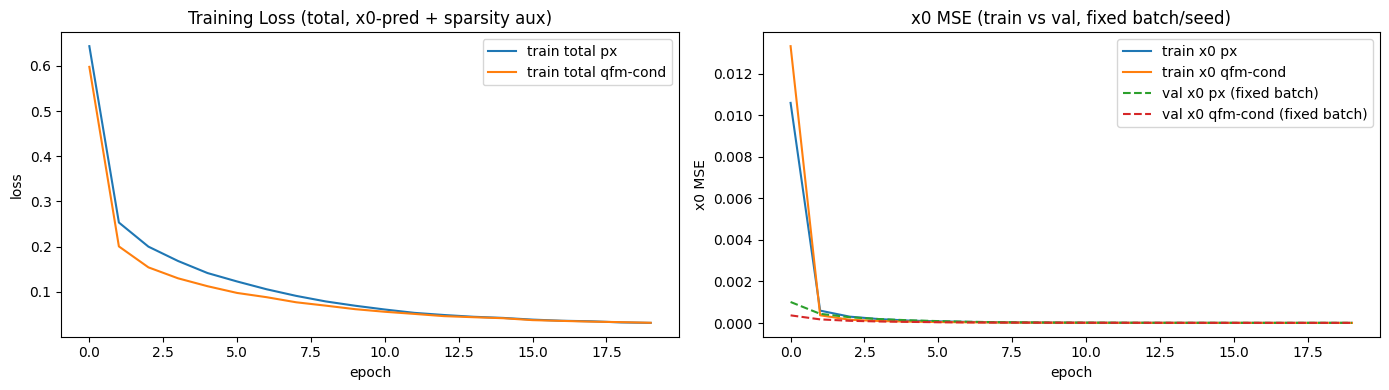

In [80]:
# Plot loss curves (compact)
# Left: total training objective (x0 MSE + sparsity aux)
# Right: x0 MSE (train vs val) overlaid for px and qfm-cond

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(train_total_px, label='train total px')
ax.plot(train_total_q, label='train total qfm-cond')
ax.set_title('Training Loss (total, x0-pred + sparsity aux)')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()

ax = axes[1]
ax.plot(train_base_px, label='train x0 px')
ax.plot(train_base_q, label='train x0 qfm-cond')
ax.plot(val_base_px, '--', label='val x0 px (fixed batch)')
ax.plot(val_base_q, '--', label='val x0 qfm-cond (fixed batch)')
ax.set_title('x0 MSE (train vs val, fixed batch/seed)')
ax.set_xlabel('epoch')
ax.set_ylabel('x0 MSE')
ax.legend()

plt.tight_layout()
plt.show()


## 7. Sampling
- Baseline: unconditional sampling in pixel space.
- QFM-conditioned: sampling conditioned on **existing** QFM features (from val set).

For fully unconditional hybrid generation later, we’d need a separate model to generate QFM features.


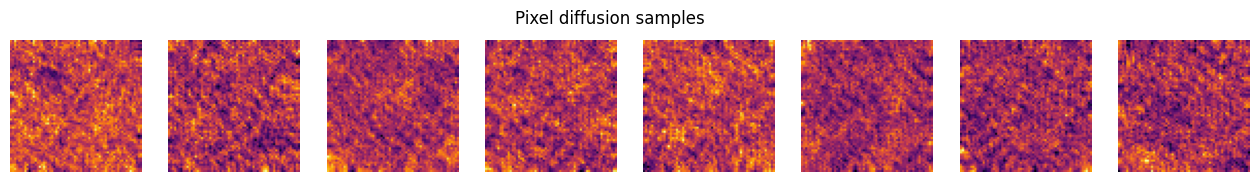

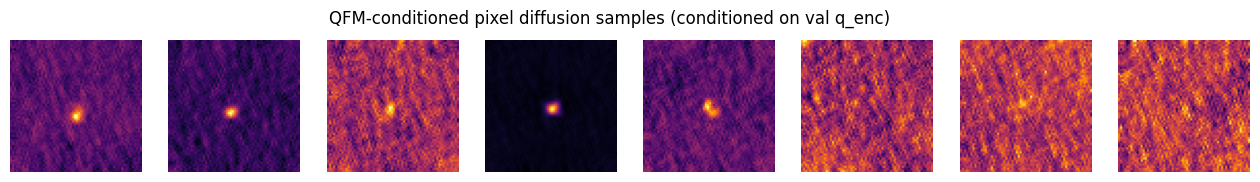

In [81]:
@torch.no_grad()
def p_sample(model, x, t, cond=None, clip_x0=True, x0_min=0.0, x0_max=1.0):
    betas_t = extract(betas, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    sqrt_om = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)

    # Model predicts x0 directly
    if cond is None:
        out = model(x, t)
        x0_pred, _, _, _ = decode_x0_from_heads(out)
    else:
        out = model(torch.cat([x, cond], dim=1), t)
        x0_pred, _, _, _ = decode_x0_from_heads(out)

    if clip_x0:
        x0_pred = torch.clamp(x0_pred, x0_min, x0_max)

    eps = predict_eps_from_x0(x, t, x0_pred)

    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps / sqrt_om)
    if (t == 0).all():
        return model_mean

    noise = torch.randn_like(x)
    var = extract(posterior_variance, t, x.shape)
    return model_mean + torch.sqrt(var) * noise

@torch.no_grad()
def p_sample_loop(model, n, cond=None, clip_x0=True):
    x = torch.randn((n, 1, 64, 64), device=device)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, cond=cond, clip_x0=clip_x0)
    return x

# Unconditional pixel samples
samples_px = p_sample_loop(model_px, n=8, clip_x0=True)
show_imgs(samples_px, n=8, title='Pixel diffusion samples')

# Conditional samples using q_enc from validation set
q_cond = upsample_cond(val_q[:8].to(device))
samples_q = p_sample_loop(model_px_qfm, n=8, cond=q_cond, clip_x0=True)
show_imgs(samples_q, n=8, title='QFM-conditioned pixel diffusion samples (conditioned on val q_enc)')



## 8. One-step reconstruction + numeric comparison
We do a quick mid-timestep reconstruction test and compute MSE/SSIM/Wasserstein.
(FID-like on raw pixels is expensive at 64x64, so we skip it here.)


MSE:   Pixel=0.000006  QFM-Cond=0.000006
SSIM:  Pixel=0.9934  QFM-Cond=0.9892
Wass:  Pixel=0.000531  QFM-Cond=0.000883


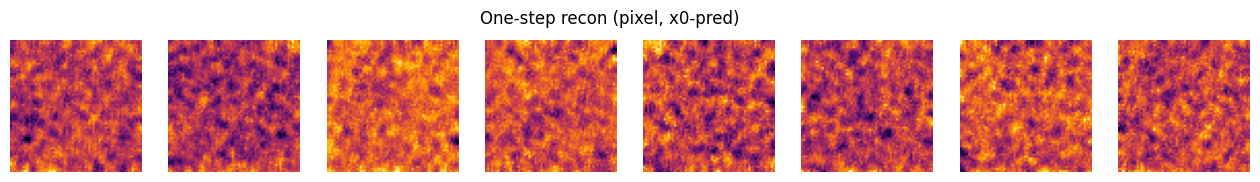

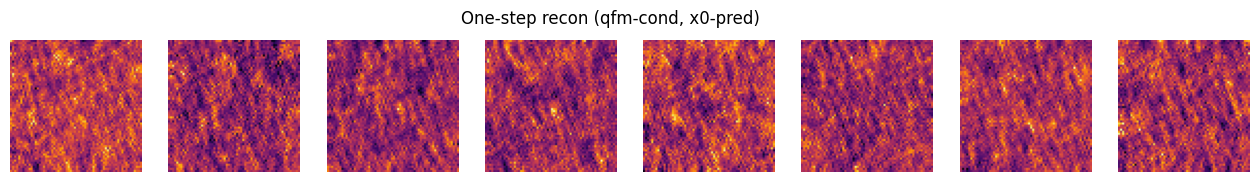

In [82]:
@torch.no_grad()
def one_step_recon_x0(model, x0, cond=None, t_val=None, gen=None):
    if t_val is None:
        t_val = torch.full((x0.shape[0],), T // 2, device=device, dtype=torch.long)
    if gen is None:
        gen = torch.Generator(device=device).manual_seed(seed + 2)

    eps = torch.randn(x0.shape, device=device, generator=gen)
    x_t = q_sample(x0, t_val, eps)

    if cond is None:
        out = model(x_t, t_val)
        x0_hat, _, _, _ = decode_x0_from_heads(out)
    else:
        out = model(torch.cat([x_t, cond], dim=1), t_val)
        x0_hat, _, _, _ = decode_x0_from_heads(out)

    return x0_hat



val_batch = val_batch_fixed
val_cond = val_cond_fixed

rec_px = one_step_recon_x0(model_px, val_batch)
rec_q = one_step_recon_x0(model_px_qfm, val_batch, cond=val_cond)

def npify(x):
    return x.detach().cpu().numpy().squeeze(1)

real = npify(val_batch)
r_px = npify(rec_px)
r_q = npify(rec_q)

real = np.clip(real, 0.0, 1.0)
r_px = np.clip(r_px, 0.0, 1.0)
r_q = np.clip(r_q, 0.0, 1.0)

def mean_ssim(a, b):
    return float(np.mean([ssim(a[i], b[i], data_range=1.0) for i in range(a.shape[0])]))

def mean_wass(a, b):
    from scipy.stats import wasserstein_distance
    return float(np.mean([wasserstein_distance(a[i].ravel(), b[i].ravel()) for i in range(a.shape[0])]))

mse_px = float(np.mean((r_px - real) ** 2))
mse_q = float(np.mean((r_q - real) ** 2))
ssim_px = mean_ssim(real, r_px)
ssim_q = mean_ssim(real, r_q)
wass_px = mean_wass(real, r_px)
wass_q = mean_wass(real, r_q)

print(f'MSE:   Pixel={mse_px:.6f}  QFM-Cond={mse_q:.6f}')
print(f'SSIM:  Pixel={ssim_px:.4f}  QFM-Cond={ssim_q:.4f}')
print(f'Wass:  Pixel={wass_px:.6f}  QFM-Cond={wass_q:.6f}')

show_imgs(rec_px, n=8, title='One-step recon (pixel, x0-pred)')
show_imgs(rec_q, n=8, title='One-step recon (qfm-cond, x0-pred)')

In [83]:
print(rec_q[:, :].max(), rec_q[:, :].min())

tensor(0.0010, device='mps:0') tensor(0.0007, device='mps:0')


Active-pixel threshold (p99.5 of real intensity01): 0.000000e+00
Frac > thr: real 0.004772186279296875 px 1.0 qfm-cond 1.0
Total energy (mean±std): real (0.2615707516670227, 0.1265254020690918) px (1.9334895610809326, 0.00029733587871305645) qfm-cond (3.391461133956909, 0.0003601099888328463)


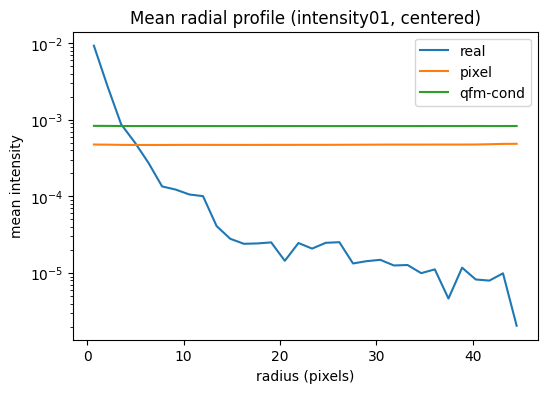

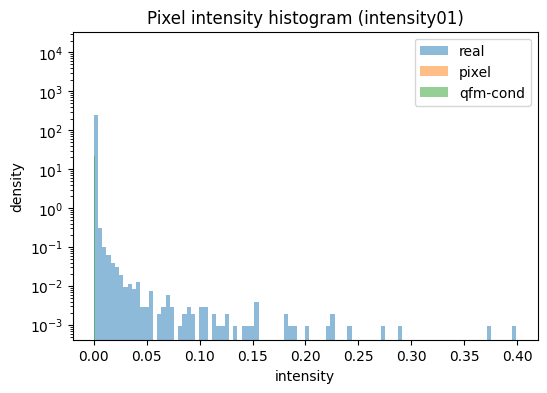

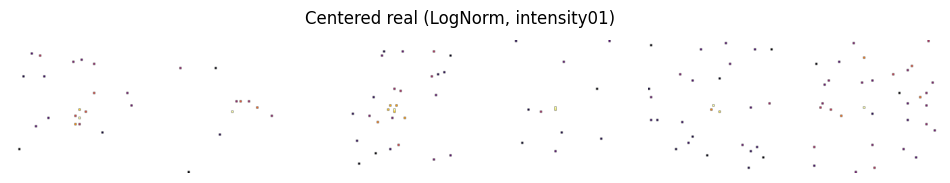

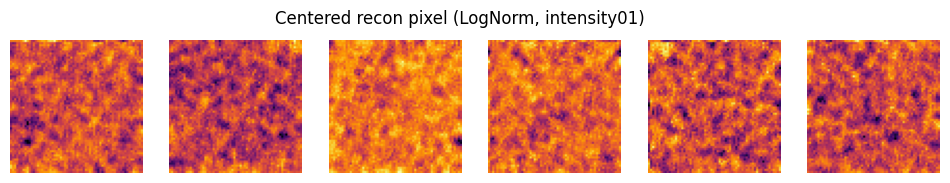

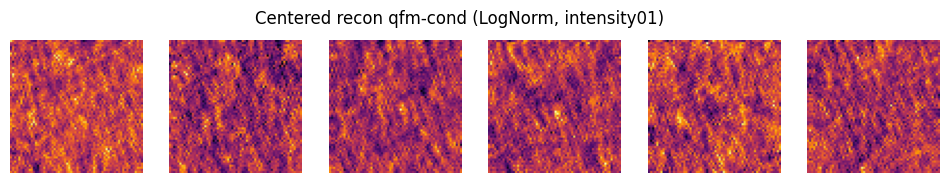

--- Sample diagnostics (centered, intensity01) ---
Frac > thr: px 1.0 qfm-cond 1.0
Total energy (mean±std): px (1.1128517389297485, 1.7876425317808753e-06) qfm-cond (0.5234476327896118, 1.4799486507399706e-06)


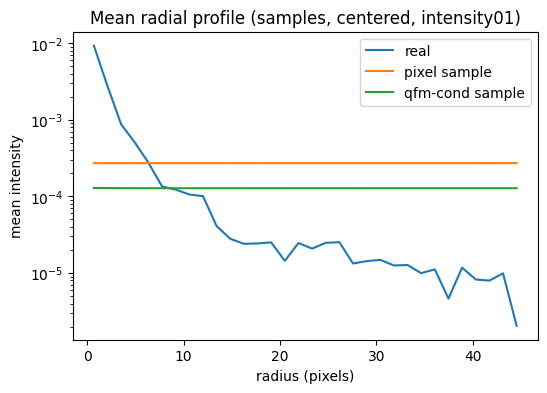

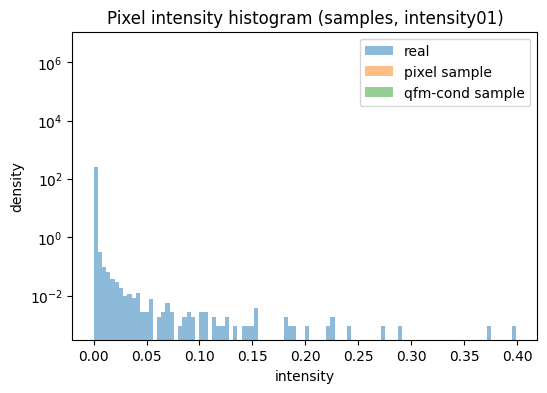

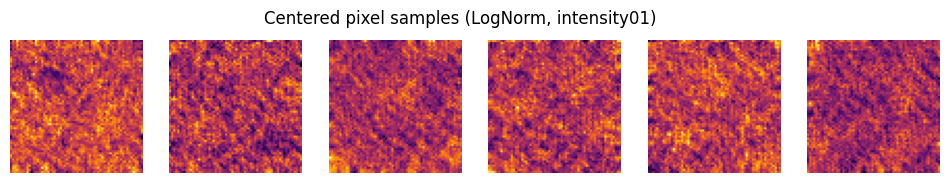

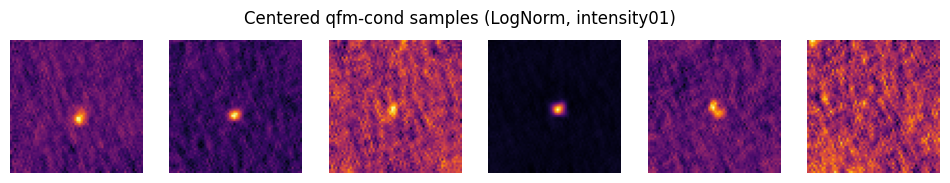

In [84]:
# Jet-aligned diagnostics (centroid alignment + sparsity-aware stats)
# Note: the training pixels are in [-1, 1]. For jet physics diagnostics we convert to an intensity-like space in [0, 1].
import matplotlib.colors as mcolors

@torch.no_grad()
def to_intensity01(x):
    # x: (N,1,H,W) in [-1,1] -> (N,1,H,W) in [0,1]
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def center_by_energy_centroid(x01, nbins=None):
    # x01: (N,1,H,W) in [0,1]
    x01 = x01.clone()
    N, _, H, W = x01.shape

    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = (H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)
    tx = (W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)

    ty = torch.round(ty).to(torch.int64)
    tx = torch.round(tx).to(torch.int64)

    out = x01
    for i in range(N):
        out[i] = torch.roll(out[i], shifts=(int(ty[i].item()), int(tx[i].item())), dims=(1,2))
    return out

@torch.no_grad()
def radial_profile(batch01, nbins=32):
    # batch01: (N,1,H,W) in [0,1]
    N, _, H, W = batch01.shape
    cy, cx = H // 2, W // 2

    yy, xx = torch.meshgrid(torch.arange(H, device=batch01.device), torch.arange(W, device=batch01.device), indexing='ij')
    rr = torch.sqrt((yy - cy)**2 + (xx - cx)**2).float()

    rmax = rr.max().item()
    bins = torch.linspace(0.0, rmax + 1e-6, nbins + 1, device=batch01.device)

    prof = torch.zeros(nbins, device=batch01.device)

    rr_flat = rr.view(-1)
    x_flat = batch01.view(N, -1)

    for b in range(nbins):
        m = (rr_flat >= bins[b]) & (rr_flat < bins[b+1])
        if m.any():
            prof[b] = x_flat[:, m].mean()

    return prof.detach().cpu().numpy(), bins.detach().cpu().numpy()

@torch.no_grad()
def total_energy01(x01):
    return x01.sum(dim=(2,3)).detach().cpu().numpy()

# Convert to intensity space and center
val01 = to_intensity01(val_batch)
rec_px01 = to_intensity01(rec_px)
rec_q01 = to_intensity01(rec_q)

val_center = center_by_energy_centroid(val01)
rec_px_center = center_by_energy_centroid(rec_px01)
rec_q_center = center_by_energy_centroid(rec_q01)

real_pos = val_center.detach().cpu().numpy().ravel()
px_pos = rec_px_center.detach().cpu().numpy().ravel()
q_pos = rec_q_center.detach().cpu().numpy().ravel()

thr = float(np.percentile(real_pos, 99.5))

def frac_above(arr, thr):
    return float(np.mean(arr > thr))

E_real = total_energy01(val_center)
E_px = total_energy01(rec_px_center)
E_q = total_energy01(rec_q_center)

print(f'Active-pixel threshold (p99.5 of real intensity01): {thr:.6e}')
print('Frac > thr: real', frac_above(real_pos, thr), 'px', frac_above(px_pos, thr), 'qfm-cond', frac_above(q_pos, thr))
print('Total energy (mean±std): real', (float(E_real.mean()), float(E_real.std())),
      'px', (float(E_px.mean()), float(E_px.std())), 'qfm-cond', (float(E_q.mean()), float(E_q.std())))

# Radial profiles
prof_real, bins = radial_profile(val_center)
prof_px, _ = radial_profile(rec_px_center)
prof_q, _ = radial_profile(rec_q_center)

r = 0.5 * (bins[:-1] + bins[1:])
plt.figure(figsize=(6,4))
plt.plot(r, prof_real, label='real')
plt.plot(r, prof_px, label='pixel')
plt.plot(r, prof_q, label='qfm-cond')
plt.yscale('log')
plt.title('Mean radial profile (intensity01, centered)')
plt.xlabel('radius (pixels)')
plt.ylabel('mean intensity')
plt.legend()
plt.show()

# Histograms
plt.figure(figsize=(6,4))
plt.hist(real_pos, bins=100, alpha=0.5, label='real', density=True)
plt.hist(px_pos, bins=100, alpha=0.5, label='pixel', density=True)
plt.hist(q_pos, bins=100, alpha=0.5, label='qfm-cond', density=True)
plt.yscale('log')
plt.title('Pixel intensity histogram (intensity01)')
plt.xlabel('intensity')
plt.ylabel('density')
plt.legend()
plt.show()

# Visualize centered images with LogNorm

def show_imgs_lognorm(x01, n=6, title=''):
    x = x01[:n].detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        img = np.clip(x[i,0], 0.0, 1.0)
        # pick vmin from positive pixels if possible
        if (img > 0).any():
            vmin = float(np.min(img[img > 0]))
        else:
            vmin = 1e-6
        vmax = float(img.max()) if img.max() > 0 else 1.0
        axes[i].imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
        axes[i].axis('off')
    if title:
        fig.suptitle(title)
    plt.show()

show_imgs_lognorm(val_center, n=6, title='Centered real (LogNorm, intensity01)')
show_imgs_lognorm(rec_px_center, n=6, title='Centered recon pixel (LogNorm, intensity01)')
show_imgs_lognorm(rec_q_center, n=6, title='Centered recon qfm-cond (LogNorm, intensity01)')

# Also diagnose full reverse-process samples (if sampling cell was run)
if 'samples_px' in globals() and 'samples_q' in globals():
    samp_px01 = to_intensity01(samples_px)
    samp_q01 = to_intensity01(samples_q)

    samp_px_center = center_by_energy_centroid(samp_px01)
    samp_q_center = center_by_energy_centroid(samp_q01)

    samp_px_pos = samp_px_center.detach().cpu().numpy().ravel()
    samp_q_pos = samp_q_center.detach().cpu().numpy().ravel()

    E_s_px = total_energy01(samp_px_center)
    E_s_q = total_energy01(samp_q_center)

    print('--- Sample diagnostics (centered, intensity01) ---')
    print('Frac > thr: px', frac_above(samp_px_pos, thr), 'qfm-cond', frac_above(samp_q_pos, thr))
    print('Total energy (mean±std): px', (float(E_s_px.mean()), float(E_s_px.std())),
          'qfm-cond', (float(E_s_q.mean()), float(E_s_q.std())))

    prof_s_px, _ = radial_profile(samp_px_center)
    prof_s_q, _ = radial_profile(samp_q_center)

    plt.figure(figsize=(6,4))
    plt.plot(r, prof_real, label='real')
    plt.plot(r, prof_s_px, label='pixel sample')
    plt.plot(r, prof_s_q, label='qfm-cond sample')
    plt.yscale('log')
    plt.title('Mean radial profile (samples, centered, intensity01)')
    plt.xlabel('radius (pixels)')
    plt.ylabel('mean intensity')
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(real_pos, bins=100, alpha=0.5, label='real', density=True)
    plt.hist(samp_px_pos, bins=100, alpha=0.5, label='pixel sample', density=True)
    plt.hist(samp_q_pos, bins=100, alpha=0.5, label='qfm-cond sample', density=True)
    plt.yscale('log')
    plt.title('Pixel intensity histogram (samples, intensity01)')
    plt.xlabel('intensity')
    plt.ylabel('density')
    plt.legend()
    plt.show()

    show_imgs_lognorm(samp_px_center, n=6, title='Centered pixel samples (LogNorm, intensity01)')
    show_imgs_lognorm(samp_q_center, n=6, title='Centered qfm-cond samples (LogNorm, intensity01)')


## Mean Centered Images

We average centered images to make global structure differences easier to see.



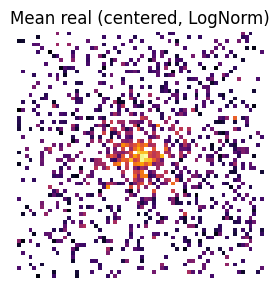

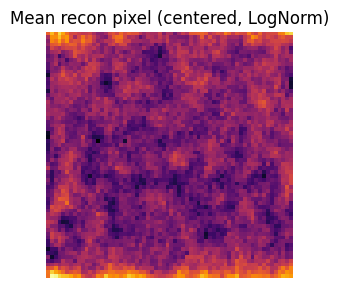

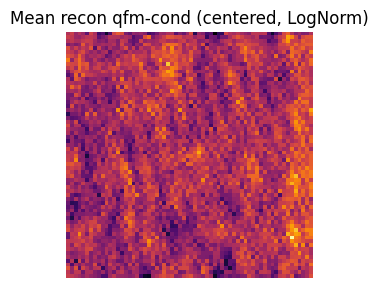

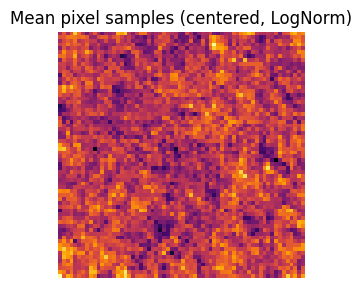

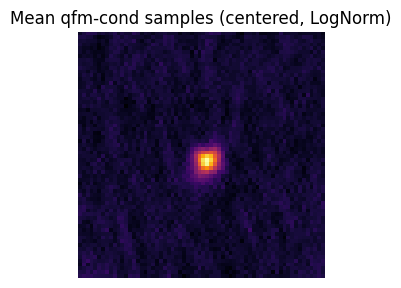

In [85]:
import matplotlib.colors as mcolors

@torch.no_grad()
def _to_intensity01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def _center_by_energy_centroid(x01):
    # wraparound centering (torch.roll)
    x01 = x01.clone()
    N, _, H, W = x01.shape

    w = x01
    w_sum = w.sum(dim=(2,3), keepdim=True) + 1e-8

    yy = torch.arange(H, device=x01.device).view(1, 1, H, 1).float()
    xx = torch.arange(W, device=x01.device).view(1, 1, 1, W).float()

    cy = (w * yy).sum(dim=(2,3), keepdim=True) / w_sum
    cx = (w * xx).sum(dim=(2,3), keepdim=True) / w_sum

    ty = (H // 2) - cy.squeeze(-1).squeeze(-1).squeeze(1)
    tx = (W // 2) - cx.squeeze(-1).squeeze(-1).squeeze(1)

    ty = torch.round(ty).to(torch.int64)
    tx = torch.round(tx).to(torch.int64)

    out = x01
    for i in range(N):
        out[i] = torch.roll(out[i], shifts=(int(ty[i].item()), int(tx[i].item())), dims=(1,2))
    return out

def mean_centered_img(x):
    x01 = _to_intensity01(x)
    x01c = _center_by_energy_centroid(x01)
    return x01c.mean(dim=0)[0].detach().cpu().numpy()  # (H,W)

def show_mean(img, title):
    plt.figure(figsize=(3.2, 3.2))
    pos = img[img > 0]
    vmin = float(pos.min()) if pos.size else 1e-6
    vmax = float(img.max()) if img.max() > 0 else 1.0
    plt.imshow(img, cmap='inferno', norm=mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Means from reconstructions (available if you ran the recon cell)
mean_real = mean_centered_img(val_batch)
mean_rec_px = mean_centered_img(rec_px)
mean_rec_q = mean_centered_img(rec_q)

show_mean(mean_real, 'Mean real (centered, LogNorm)')
show_mean(mean_rec_px, 'Mean recon pixel (centered, LogNorm)')
show_mean(mean_rec_q, 'Mean recon qfm-cond (centered, LogNorm)')

# Means from full samples (only if you ran sampling)
if 'samples_px' in globals() and 'samples_q' in globals():
    mean_s_px = mean_centered_img(samples_px)
    mean_s_q = mean_centered_img(samples_q)
    show_mean(mean_s_px, 'Mean pixel samples (centered, LogNorm)')
    show_mean(mean_s_q, 'Mean qfm-cond samples (centered, LogNorm)')
else:
    print('Sampling tensors not found (run the sampling cell first): samples_px, samples_q')

In [ ]:
# Top-k / top-1% (whichever fewer) high-intensity pixel visualization for generated samples
# Each row is a *corresponding* sample: (pixel | qfm-cond)

if 'samples_px' not in globals() or 'samples_q' not in globals():
    print('Run the sampling cell first to create samples_px and samples_q')
else:
    samp_px01 = _to_intensity01(samples_px)
    samp_q01 = _to_intensity01(samples_q)

    samp_px_center = _center_by_energy_centroid(samp_px01)
    samp_q_center = _center_by_energy_centroid(samp_q01)

    n_show = min(6, int(samp_px_center.shape[0]), int(samp_q_center.shape[0]))
    H, W = int(samp_px_center.shape[2]), int(samp_px_center.shape[3])
    k_1pct = max(1, int(0.01 * H * W))
    k = min(30, k_1pct)
    print(f'Top-k visualization: k={k} (min(30, 1%={k_1pct}) of {H}x{W})')

    def _topk_points(img01):
        flat = img01.view(-1)
        kk = min(k, flat.numel())
        vals, idx = torch.topk(flat, kk)
        ys = (idx // W).detach().cpu().numpy()
        xs = (idx % W).detach().cpu().numpy()
        vv = vals.detach().cpu().numpy()
        return xs, ys, vv

    fig, axes = plt.subplots(n_show, 2, figsize=(6, 2.2 * n_show), constrained_layout=True)
    if n_show == 1:
        axes = np.array(axes).reshape(1, 2)

    for i in range(n_show):
        img_px = samp_px_center[i, 0]
        img_q = samp_q_center[i, 0]

        x1, y1, v1 = _topk_points(img_px)
        x2, y2, v2 = _topk_points(img_q)

        vmax = float(max(v1.max() if v1.size else 0.0, v2.max() if v2.size else 0.0, 1e-6))
        vpos = np.concatenate([v1[v1 > 0], v2[v2 > 0]])
        vmin = float(vpos.min()) if vpos.size else 1e-6
        norm = mcolors.LogNorm(vmin=max(vmin, 1e-6), vmax=vmax)

        ax = axes[i, 0]
        ax.scatter(x1, y1, c=v1, cmap='inferno', norm=norm, s=18)
        if i == 0:
            ax.set_title('pixel top-k')
        ax.set_xlim(-0.5, W - 0.5)
        ax.set_ylim(H - 0.5, -0.5)
        ax.set_xticks([])
        ax.set_yticks([])

        ax = axes[i, 1]
        ax.scatter(x2, y2, c=v2, cmap='inferno', norm=norm, s=18)
        if i == 0:
            ax.set_title('qfm-cond top-k')
        ax.set_xlim(-0.5, W - 0.5)
        ax.set_ylim(H - 0.5, -0.5)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle('Highest-intensity pixel locations (centered samples), per-sample row: pixel | qfm-cond', y=1.01)
    plt.show()
